<a href="https://colab.research.google.com/github/saraahmed0706-2/AI-PLC_Ladder_Logic_ProjectASE/blob/main/AI_PLC_Ladder_Logic_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 49.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy
nlp = spacy.load('en_core_web_sm')

In [ ]:
def parse_instruction(text):
    doc = nlp(text.lower())

    data = {
        "actions": [],
        "conditions": [],
        "devices": [],
        "timers": None,
        "safety": False
    }

    inputs = ["sensor", "button", "switch"]
    outputs = ["motor", "pump", "conveyor"]

    for token in doc:
        word = token.text

        if word in ["start", "stop"]:
            data["actions"].append(word)

        if word in inputs:
            data["conditions"].append(word.capitalize())

        if word in outputs:
            data["devices"].append(word.capitalize())

        if "second" in word:
            for t in doc:
                if t.like_num:
                    data["timers"] = int(t.text)

    if "emergency" in text.lower():
        data["safety"] = True

    return data

In [ ]:
def generate_logic(parsed_data):
    logic = []

    # Inputs
    for cond in parsed_data["conditions"]:
        logic.append(("XIC", cond))

    # Safety
    if parsed_data["safety"]:
        logic.append(("XIO", "Emergency_Stop"))

    # Outputs
    if "start" in parsed_data["actions"]:
        for device in parsed_data["devices"]:
            logic.append(("OTE", device))

    # Timer
    if parsed_data["timers"]:
        logic.append(("TON", f"TIMER_{parsed_data['timers']}s"))

    return logic

In [ ]:
def generate_ladder(logic):
    rung = "| "

    for item in logic:
        if item[0] == "XIC":
            rung += f"[ {item[1]} ] "

        elif item[0] == "XIO":
            rung += f"[/{item[1]}] "

        elif item[0] == "OTE":
            rung += f"( {item[1]} ) "

        elif item[0] == "TON":
            rung += f"(TON {item[1]}) "

    rung += "|"
    return rung

In [ ]:
def check_safety(parsed_data):
    warnings = []

    if not parsed_data["safety"]:
        warnings.append("⚠️ No emergency stop included!")

    if not parsed_data["conditions"]:
        warnings.append("⚠️ No input condition defined!")

    return warnings

In [ ]:
def export_to_file(ladder_code):
    with open("ladder_logic.txt", "w") as f:
        f.write(ladder_code)

    print("File saved as ladder_logic.txt")

# Define the instruction variable
instruction = "Start motor when button is pressed"

# Save output
export_to_file(generate_ladder(generate_logic(parse_instruction(instruction))))

File saved as ladder_logic.txt


In [ ]:
!pip install scikit-learn

In [ ]:
actions = ["Start", "Activate", "Run", "Turn on"]
devices = ["motor", "pump", "conveyor"]
conditions = ["button is pressed", "sensor detects object", "switch is on"]
safety = ["", " with emergency stop"]
timers = ["", " and stop after 5 seconds", " and stop after 10 seconds"]

data = []

for action in actions:
    for device in devices:
        for condition in conditions:
            for s in safety:
                for t in timers:

                    sentence = f"{action} {device} when {condition}{t}{s}"

                    label = f"XIC {condition.split()[0].capitalize()} OTE {device.capitalize()}"

                    if "emergency" in s:
                        label = f"XIC {condition.split()[0].capitalize()} XIO Emergency_Stop OTE {device.capitalize()}"

                    if "seconds" in t:
                        label = f"{label} TON Timer"

                    data.append((sentence, label))

data = list(set(data))

print("Dataset Size:", len(data))

Dataset Size: 216


In [ ]:
texts = [x[0] for x in data]
labels = [x[1] for x in data]

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(texts)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X, labels)

print("Model Training Completed ✅")

Model Training Completed ✅


In [ ]:
def predict_logic(text):
    text_vectorized = vectorizer.transform([text])
    prediction = model.predict(text_vectorized)
    return prediction[0]

print(predict_logic("Start motor when button is pressed"))
print(predict_logic("Start conveyor when sensor detects object"))
print(predict_logic("Turn on pump when switch is active"))

XIC Button OTE Motor TON Timer
XIC Sensor OTE Conveyor TON Timer
XIC Switch OTE Pump TON Timer


In [ ]:
y_pred = model.predict(X_test_vec)

In [ ]:
def to_ladder(text):
    result = predict_logic(text)

    ladder = " | "

    parts = result.split()

    for p in parts:
        ladder += p + " "

    return ladder + "|"

In [ ]:
def run_system(input_text):
    print("\nInput:", input_text)

    result = predict_logic(input_text)
    print("AI Output:", result)

    print("Ladder Logic:", to_ladder(input_text))


run_system("Start motor when button is pressed")


Input: Start motor when button is pressed
AI Output: XIC Button OTE Motor TON Timer
Ladder Logic:  | XIC Button OTE Motor TON Timer |


In [ ]:
from google.colab import files
files.download("ladder_logic.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
run_system("Start motor when button is pressed")
run_system("Start pump when sensor detects level and stop after 5 seconds")
run_system("Start conveyor without emergency stop")


Input: Start motor when button is pressed
AI Output: XIC Button OTE Motor TON Timer
Ladder Logic:  | XIC Button OTE Motor TON Timer |

Input: Start pump when sensor detects level and stop after 5 seconds
AI Output: XIC Sensor OTE Pump TON Timer
Ladder Logic:  | XIC Sensor OTE Pump TON Timer |

Input: Start conveyor without emergency stop
AI Output: XIC Switch XIO Emergency_Stop OTE Conveyor TON Timer
Ladder Logic:  | XIC Switch XIO Emergency_Stop OTE Conveyor TON Timer |


In [ ]:
devices = ["motor", "pump", "conveyor"]

In [ ]:
import ipywidgets as widgets
from IPython.display import display

text = widgets.Text(description="Input:")
button = widgets.Button(description="Generate")

def on_click(b):
    run_system(text.value)

button.on_click(on_click)

display(text, button)

Text(value='', description='Input:')

Button(description='Generate', style=ButtonStyle())

In [ ]:
from sklearn.metrics import classification_report

# Generate report
report = classification_report(y_test, y_pred)

print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

    Conveyor       1.00      1.00      1.00         1
       Motor       0.00      0.00      0.00         2
        Pump       0.00      0.00      0.00         0

    accuracy                           0.33         3
   macro avg       0.33      0.33      0.33         3
weighted avg       0.33      0.33      0.33         3



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

Accuracy: 1.0


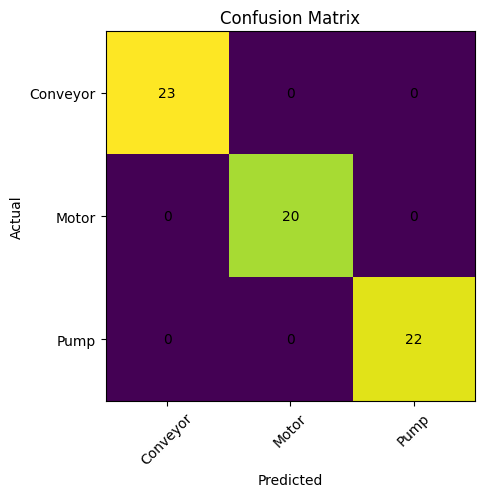

<Figure size 640x480 with 0 Axes>

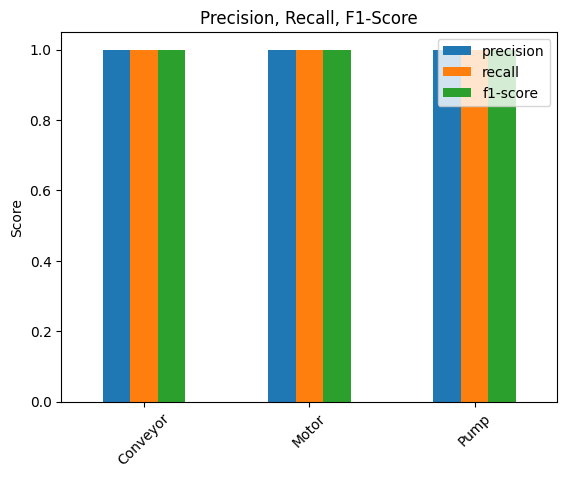

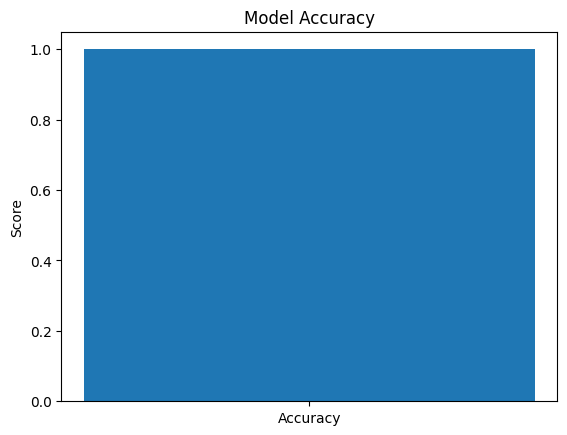

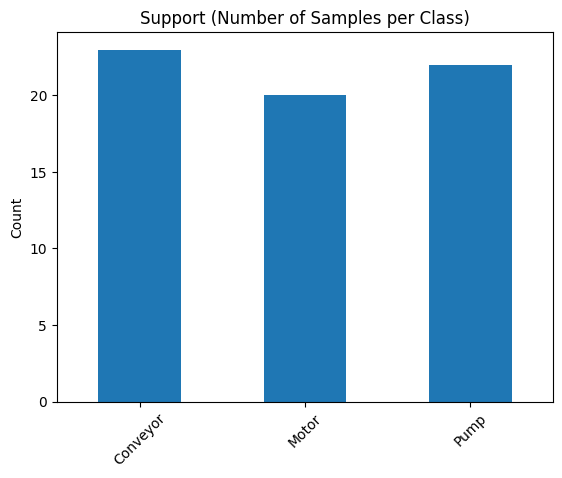

In [ ]:
# Complete evaluation with graphs using generated dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --------- DATA GENERATION ---------
actions = ["Start", "Activate", "Run", "Turn on"]
devices = ["motor", "pump", "conveyor"]
conditions = ["button is pressed", "sensor detects object", "switch is on"]
safety = ["", " with emergency stop"]
timers = ["", " and stop after 5 seconds", " and stop after 10 seconds"]

data = []

for action in actions:
    for device in devices:
        for condition in conditions:
            for s in safety:
                for t in timers:
                    sentence = f"{action} {device} when {condition}{t}{s}"
                    label = device.capitalize()
                    data.append((sentence, label))

data = list(set(data))

texts = [x[0] for x in data]
labels = [x[1] for x in data]

# --------- TRAIN TEST SPLIT ---------
X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.3, random_state=42)

# --------- VECTORIZE ---------
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# --------- TRAIN MODEL ---------
model = LogisticRegression()
model.fit(X_train_vec, y_train)

# --------- PREDICTION ---------
y_pred = model.predict(X_test_vec)

# --------- ACCURACY ---------
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# --------- CONFUSION MATRIX ---------
cm = confusion_matrix(y_test, y_pred)
classes = list(set(labels))

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xticks(np.arange(len(classes)), classes, rotation=45)
plt.yticks(np.arange(len(classes)), classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

# --------- CLASSIFICATION REPORT ---------
report = classification_report(y_test, y_pred, output_dict=True)
df = pd.DataFrame(report).transpose()

# Remove avg rows for clean graph
df_plot = df.iloc[:-3]

# --------- PRECISION / RECALL / F1 GRAPH ---------
plt.figure()
df_plot[['precision', 'recall', 'f1-score']].plot(kind='bar')
plt.title("Precision, Recall, F1-Score")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

# --------- ACCURACY BAR GRAPH ---------
plt.figure()
plt.bar(["Accuracy"], [accuracy])
plt.title("Model Accuracy")
plt.ylabel("Score")
plt.show()

# --------- SUPPORT GRAPH ---------
plt.figure()
df_plot['support'].plot(kind='bar')
plt.title("Support (Number of Samples per Class)")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()